<a href="https://colab.research.google.com/github/DarkLauroDFreitas/Calculo_N-merico_1_Miguel/blob/main/CN_atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CN atividade 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def simular(dt, tipo=np.float32, passos=120, pontos=21):
    """Simula difusão de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numérico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numéricos em exceções.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo

                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )

                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

In [ ]:
print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


dt=0.001, float32: 120 passos sem overflow.
dt=0.002, float32: 120 passos sem overflow.
dt=0.001, float64: 120 passos sem overflow.
dt=0.002, float64: 120 passos sem overflow.


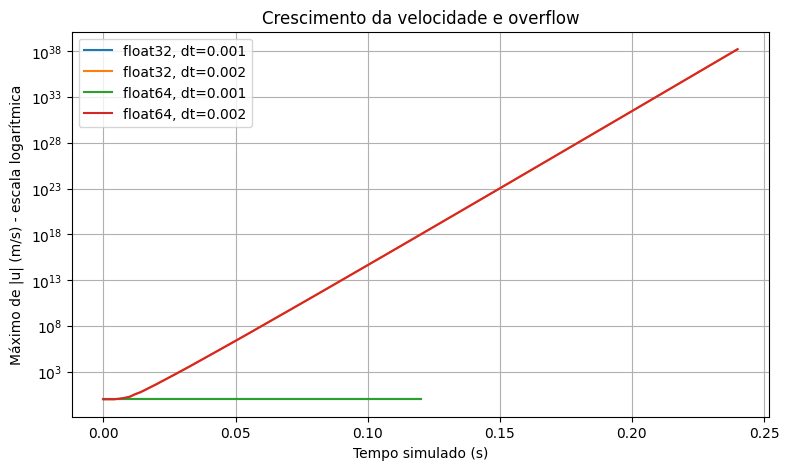

In [ ]:
resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)


plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()